# PhoBERT DoRA Benchmark

Notebook này tổng hợp benchmark Full Fine-Tuning, LoRA và DoRA cho PhoBERT trên UIT-VSFC. Logic train chính nằm trong `train.py`; notebook chỉ gọi script hoặc đọc `results/benchmark_results.csv`.

In [36]:
from pathlib import Path
import itertools
import os
import shlex
import subprocess
import sys

if sys.platform.startswith('win'):
    import asyncio
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results' / 'benchmark_results_2.csv'
ROOT, RESULTS

(WindowsPath('c:/Users/letie/OneDrive/Documents/GitHub/PEFT-from-scartch'),
 WindowsPath('c:/Users/letie/OneDrive/Documents/GitHub/PEFT-from-scartch/results/benchmark_results_2.csv'))

## GPU diagnostics

Run this cell before training. It checks whether the active notebook kernel has a CUDA-enabled PyTorch build, not just whether the machine has an NVIDIA GPU.

In [37]:
import platform
import torch

print('Python:', sys.executable)
print('Platform:', platform.platform())
print('PyTorch:', torch.__version__)
print('PyTorch CUDA build:', torch.version.cuda)
print('CUDA available:', torch.cuda.is_available())
print('CUDA device count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    major, minor = torch.cuda.get_device_capability(0)
    print('Compute capability:', f'{major}.{minor}')
else:
    print('This environment is using CPU-only PyTorch or cannot access CUDA.')
    print('Install a CUDA-enabled PyTorch wheel in this exact environment:')
    print(f'{sys.executable} -m pip install --upgrade --index-url https://download.pytorch.org/whl/cu129 torch torchvision torchaudio')

Python: c:\Users\letie\anaconda3\envs\esg_nlp_research_version_2\python.exe
Platform: Windows-10-10.0.22631-SP0
PyTorch: 2.8.0+cu129
PyTorch CUDA build: 12.9
CUDA available: True
CUDA device count: 1
GPU: NVIDIA GeForce RTX 3060
Compute capability: 8.6


## Download model and dataset

Set `DOWNLOAD_ASSETS = True` and run this cell once when you have internet. Hugging Face will cache PhoBERT locally, so later training runs can use the local cache. If your network blocks Hugging Face, download will fail here before training starts.

In [38]:
DOWNLOAD_ASSETS = False
MODEL_NAME = 'vinai/phobert-base-v2'
DATASET_NAME = 'uitnlp/vietnamese_students_feedback'
LOCAL_FILES_ONLY = False
FORCE_DOWNLOAD = False

if DOWNLOAD_ASSETS:
    os.environ.setdefault('HF_HUB_DISABLE_SYMLINKS_WARNING', '1')
    from datasets import load_dataset
    from huggingface_hub import snapshot_download
    from transformers import AutoConfig, AutoModelForSequenceClassification, AutoTokenizer

    try:
        model_cache_dir = snapshot_download(
            repo_id=MODEL_NAME,
            local_files_only=LOCAL_FILES_ONLY,
            force_download=FORCE_DOWNLOAD,
        )
        tokenizer = AutoTokenizer.from_pretrained(model_cache_dir, use_fast=False, local_files_only=True)
        config = AutoConfig.from_pretrained(model_cache_dir, num_labels=3, local_files_only=True)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_cache_dir,
            config=config,
            local_files_only=True,
            ignore_mismatched_sizes=True,
        )
        dataset = load_dataset(DATASET_NAME, trust_remote_code=True)
        print('PhoBERT cache:', model_cache_dir)
        print('Tokenizer vocab size:', len(tokenizer))
        print('Model loaded:', type(model).__name__)
        print(dataset)
    except Exception as exc:
        print('Download failed.')
        print('Common causes: no internet, firewall blocks huggingface.co, or missing dependency from requirements.txt.')
        print('Original error:')
        raise exc
else:
    print('Set DOWNLOAD_ASSETS = True to download PhoBERT and UIT-VSFC into the local Hugging Face cache.')

Set DOWNLOAD_ASSETS = True to download PhoBERT and UIT-VSFC into the local Hugging Face cache.


## Run benchmark commands

Cell này luôn có thể chạy một lệnh kiểm tra trực tiếp (`python train.py --help`). Để train thật, set `RUN_TRAINING = True`. Nên bắt đầu với `TRAIN_MODE = 'single'` hoặc `'smoke'` trước khi chạy benchmark đầy đủ.

In [60]:
RUN_DIRECT_CHECK = True
RUN_TRAINING = True
TRAIN_MODE = 'benchmark'  # 'single', 'smoke', or 'benchmark'
DATASET = 'data/uit_vion/subset.csv'
seeds = [97, 98, 99]
ranks = [8, 16]
smoke_args = ['--epochs', '1', '--max-train-samples', '64', '--max-eval-samples', '64', '--dataset', str(DATASET), '--results-file', str(RESULTS)]

def printable_command(cmd):
    return ' '.join(shlex.quote(str(part)) for part in cmd)

def run_command(cmd):
    cmd = list(cmd)
    if Path(str(cmd[0])).name.lower().startswith('python') or str(cmd[0]).lower().endswith('python.exe'):
        if len(cmd) == 1 or cmd[1] != '-u':
            cmd.insert(1, '-u')
    print('$', printable_command(cmd), flush=True)
    env = os.environ.copy()
    env['PYTHONUNBUFFERED'] = '1'
    process = subprocess.Popen(
        cmd,
        cwd=ROOT,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,
        env=env,
    )
    assert process.stdout is not None
    for line in process.stdout:
        print(line, end='', flush=True)
    return_code = process.wait()
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, cmd)
    return return_code

def check_accelerate():
    check_cmd = [sys.executable, '-m', 'pip', 'show', 'accelerate']
    completed = subprocess.run(check_cmd, cwd=ROOT, text=True, capture_output=True)
    if completed.returncode == 0:
        print('accelerate is installed for this kernel Python.')
        return True
    install_cmd = [sys.executable, '-m', 'pip', 'install', '-r', str(ROOT / 'requirements.txt')]
    print('Missing accelerate in this kernel Python.')
    print('Run this command in a notebook cell or terminal:')
    print(printable_command(install_cmd))
    return False

direct_check_command = [sys.executable, 'train.py', '--help']

single_train_command = [
    sys.executable, 'train.py', '--method', 'dora', '--rank', '8', '--alpha', '16',
    '--dropout', '0.05', '--seed', '42', '--output-dir', 'outputs',
    '--epochs', '1', '--max-train-samples', '64', '--max-eval-samples', '64', '--results-file', str(RESULTS)
]

benchmark_commands = []
for seed in seeds:
    benchmark_commands.append([sys.executable, 'train.py', '--method', 'ft', '--seed', str(seed), '--dataset',str(DATASET), '--output-dir', 'outputs', '--results-file', str(RESULTS)])
    for method, rank in itertools.product(['lora', 'dora'], ranks):
        benchmark_commands.append([
            sys.executable, 'train.py', '--method', method, '--rank', str(rank), '--alpha', str(2 * rank),
            '--dropout', '0.05', '--seed', str(seed),'--dataset', str(DATASET), '--output-dir', 'outputs', '--results-file', str(RESULTS),
        ])

if TRAIN_MODE == 'single':
    commands = [single_train_command]
elif TRAIN_MODE == 'smoke':
    commands = [cmd + smoke_args for cmd in benchmark_commands[:3]]
elif TRAIN_MODE == 'benchmark':
    commands = benchmark_commands
else:
    raise ValueError("TRAIN_MODE must be 'single', 'smoke', or 'benchmark'")

runtime_ready = check_accelerate()
if RUN_DIRECT_CHECK:
    run_command(direct_check_command)

print('\nTraining commands:')
for cmd in commands:
    print(printable_command(cmd))

if RUN_TRAINING:
    if not runtime_ready:
        raise RuntimeError('Install dependencies first, then rerun this cell.')
    for cmd in commands:
        run_command(cmd)
else:
    print('\nSet RUN_TRAINING = True to execute the training commands above.')

accelerate is installed for this kernel Python.
$ 'c:\Users\letie\anaconda3\envs\esg_nlp_research_version_2\python.exe' -u train.py --help
True
NVIDIA GeForce RTX 3060
usage: train.py [-h] --method {ft,lora,dora} [--model-name MODEL_NAME]
                [--dataset DATASET] [--task-type {single_label,multi_label}]
                [--label-map LABEL_MAP] [--label-threshold LABEL_THRESHOLD]
                [--rank RANK] [--alpha ALPHA] [--dropout DROPOUT]
                [--seed SEED] [--output-dir OUTPUT_DIR]
                [--results-file RESULTS_FILE]
                [--target-modules TARGET_MODULES] [--epochs EPOCHS]
                [--learning-rate LEARNING_RATE] [--batch-size BATCH_SIZE]
                [--eval-batch-size EVAL_BATCH_SIZE] [--max-length MAX_LENGTH]
                [--max-train-samples MAX_TRAIN_SAMPLES]
                [--max-eval-samples MAX_EVAL_SAMPLES]
                [--init-magnitude {weight_norm,ones}] [--no-detach]

PhoBERT FT/LoRA/DoRA benchmark trainer

o

## Aggregate results

In [61]:
import pandas as pd
from IPython.display import display

df = pd.read_csv(RESULTS) if RESULTS.exists() else pd.DataFrame()
if df.empty or df.dropna(how='all').empty:
    print(f'No benchmark rows found yet: {RESULTS}')
    print('Run train.py or set RUN_TRAINING = True above, then rerun this notebook.')
else:
    df = df.dropna(subset=['method'], how='any')
    df = df.dropna(axis=1, how='all')
display(df)

,run_id,method,model_name,dataset,task_type,rank,alpha,dropout,seed,init_magnitude,...,accuracy,macro_f1,weighted_f1,trainable_params,total_params,trainable_percent,train_time_sec,peak_vram_mb,checkpoint_size_mb,output_dir
0,ft_seed97_1781723194,ft,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,NaN,NaN,NaN,97,NaN,...,0.813077,0.812927,0.812927,135008269,135008269,100.000000,515.091151,2088.181641,8253.025409,outputs\ft_seed97_1781723194
1,lora_r8_seed97_1781723738,lora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,8.0,16.0,0.05,97,NaN,...,0.800769,0.800033,0.800033,895501,135303181,0.661848,287.051616,774.799316,3.433017,outputs\lora_r8_seed97_1781723738
2,lora_r16_seed97_1781724042,lora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,16.0,32.0,0.05,97,NaN,...,0.799615,0.798981,0.798981,1190413,135598093,0.877898,373.618578,778.502441,4.558017,outputs\lora_r16_seed97_1781724042
3,dora_r8_seed97_1781724430,dora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,8.0,16.0,0.00,97,weight_norm,...,0.803462,0.802582,0.802582,913933,121165837,0.754283,302.214865,870.607910,3.511088,outputs\dora_r8_seed97_1781724430
4,dora_r16_seed97_1781724745,dora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,16.0,32.0,0.00,97,weight_norm,...,0.801923,0.801658,0.801658,1208845,121460749,0.995256,290.500627,873.982910,4.636088,outputs\dora_r16_seed97_1781724745
5,ft_seed98_1781725049,ft,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,NaN,NaN,NaN,98,NaN,...,0.810000,0.809102,0.809102,135008269,135008269,100.000000,526.694737,2089.023438,8253.025690,outputs\ft_seed98_1781725049
6,lora_r8_seed98_1781725591,lora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,8.0,16.0,0.05,98,NaN,...,0.796923,0.795997,0.795997,895501,135303181,0.661848,252.846794,772.886230,3.433017,outputs\lora_r8_seed98_1781725591
7,lora_r16_seed98_1781725859,lora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,16.0,32.0,0.05,98,NaN,...,0.800000,0.799257,0.799257,1190413,135598093,0.877898,236.807682,776.589355,4.558017,outputs\lora_r16_seed98_1781725859
8,dora_r8_seed98_1781726109,dora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,8.0,16.0,0.00,98,weight_norm,...,0.803077,0.802567,0.802567,913933,121165837,0.754283,258.144817,871.232910,3.511088,outputs\dora_r8_seed98_1781726109
9,dora_r16_seed98_1781726380,dora,vinai/phobert-base-v2,data/uit_vion/subset.csv,single_label,16.0,32.0,0.00,98,weight_norm,...,0.804231,0.803790,0.803790,1208845,121460749,0.995256,256.178730,874.607910,4.636088,outputs\dora_r16_seed98_1781726380


In [62]:
if df.empty:
    summary = pd.DataFrame()
else:
    summary = (
        df.groupby(['method', 'rank'], dropna=False)
        .agg(
            accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
            macro_f1_mean=('macro_f1', 'mean'), macro_f1_std=('macro_f1', 'std'),
            weighted_f1_mean=('weighted_f1', 'mean'), weighted_f1_std=('weighted_f1', 'std'),
            trainable_percent_mean=('trainable_percent', 'mean'),
            peak_vram_mb_mean=('peak_vram_mb', 'mean'),
            train_time_sec_mean=('train_time_sec', 'mean'),
            checkpoint_size_mb_mean=('checkpoint_size_mb', 'mean'),
            runs=('run_id', 'count'),
        )
        .reset_index()
        .sort_values(['method', 'rank'])
    )
display(summary)

,method,rank,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,trainable_percent_mean,peak_vram_mb_mean,train_time_sec_mean,checkpoint_size_mb_mean,runs
0,dora,8.0,0.803077,0.000385,0.802433,0.000245,0.802433,0.000245,0.754283,870.816243,276.926287,3.511088,3
1,dora,16.0,0.803590,0.001456,0.803176,0.001322,0.803176,0.001322,0.995256,874.191243,267.241237,4.636088,3
2,ft,NaN,0.810897,0.001897,0.810176,0.002402,0.810176,0.002402,100.000000,2089.076172,513.009800,8253.025411,3
3,lora,8.0,0.798205,0.002221,0.797615,0.002133,0.797615,0.002133,0.661848,773.128092,260.202318,3.433017,3
4,lora,16.0,0.798718,0.001897,0.798167,0.001653,0.798167,0.001653,0.877898,776.831217,302.049765,4.558017,3


## Plots

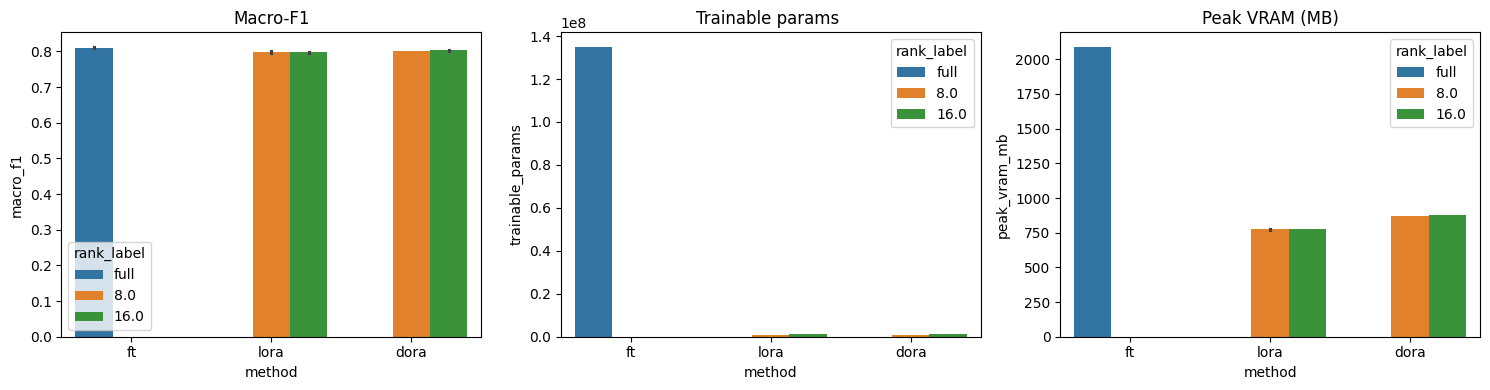

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

if df.empty:
    print('No benchmark rows to plot yet.')
else:
    plot_df = df.copy()
    plot_df['rank_label'] = plot_df['rank'].fillna('full').astype(str)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sns.barplot(data=plot_df, x='method', y='macro_f1', hue='rank_label', ax=axes[0])
    axes[0].set_title('Macro-F1')
    sns.barplot(data=plot_df, x='method', y='trainable_params', hue='rank_label', ax=axes[1])
    axes[1].set_title('Trainable params ')
    sns.barplot(data=plot_df, x='method', y='peak_vram_mb', hue='rank_label', ax=axes[2])
    axes[2].set_title('Peak VRAM (MB)')
    plt.tight_layout()

## DoRA merge check

In [64]:
import torch
from torch import nn
from src.peft import DoRALinear

torch.manual_seed(0)
linear = nn.Linear(8, 4)
dora = DoRALinear.from_linear(linear, rank=2, alpha=4)
dora.lora_B.data.normal_(0, 0.02)
x = torch.randn(3, 8)
merged = dora.merge()
max_diff = (dora(x) - merged(x)).abs().max().item()
max_diff

0.0